In [1]:
!nvcc --version
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpkbi1rvwu".


In [2]:
# Скрипт для запуска CUDA программы на T4 в Google Colab

# 1. Проверка доступного GPU
!nvidia-smi
print("\n" + "="*60)

# 2. Установка правильной версии CUDA Toolkit для T4
!apt-get update
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64/cuda-keyring_1.0-1_all.deb
!dpkg -i cuda-keyring_1.0-1_all.deb
!apt-get update
!apt-get -y install cuda-toolkit-11-8

# 3. Настройка переменных окружения
import os
os.environ['PATH'] = '/usr/local/cuda-11.8/bin:' + os.environ['PATH']
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-11.8/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')

# 4. Проверка установки
!nvcc --version
print("\n" + "="*60)

Tue Jun  2 19:33:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [21]:
%%writefile vector_sum.cu
#include <iostream>
#include <vector>
#include <chrono>
#include <cmath>
#include <cuda_runtime.h>

#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            std::cerr << "CUDA error: " << cudaGetErrorString(err) << std::endl; \
            exit(EXIT_FAILURE); \
        } \
    } while(0)

// CPU: простой цикл
float sumCPU(const float* data, int n) {
    float sum = 0.0f;
    for (int i = 0; i < n; ++i) {
        sum += data[i];
    }
    return sum;
}

// GPU kernel
__global__ void sumKernel(const float* d_in, float* d_out, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    float local_sum = 0.0f;
    for (int i = idx; i < n; i += stride) {
        local_sum += d_in[i];
    }
    atomicAdd(d_out, local_sum);
}

int main(int argc, char* argv[]) {
    if (argc != 2) {
        std::cerr << "Usage: " << argv[0] << " <vector_size>" << std::endl;
        return 1;
    }

    int N = std::atoi(argv[1]);
    std::vector<float> data(N);
    srand(42);
    for (int i = 0; i < N; ++i) {
        data[i] = static_cast<float>(rand()) / RAND_MAX;
    }

    // --- CPU ---
    auto t0 = std::chrono::high_resolution_clock::now();
    float cpu_sum = sumCPU(data.data(), N);
    auto t1 = std::chrono::high_resolution_clock::now();
    double cpu_ms = std::chrono::duration<double, std::milli>(t1 - t0).count();

    // --- GPU ---
    size_t bytes = N * sizeof(float);
    float *d_in, *d_out;
    CUDA_CHECK(cudaMalloc(&d_in, bytes));
    CUDA_CHECK(cudaMalloc(&d_out, sizeof(float)));
    CUDA_CHECK(cudaMemset(d_out, 0, sizeof(float)));

    // Копирование ВХОДНЫХ данных (входит в total, не входит в kernel)
    auto tr0 = std::chrono::high_resolution_clock::now();
    CUDA_CHECK(cudaMemcpy(d_in, data.data(), bytes, cudaMemcpyHostToDevice));
    auto tr1 = std::chrono::high_resolution_clock::now();
    double h2d_ms = std::chrono::duration<double, std::milli>(tr1 - tr0).count();

    int blockSize = 256;
    int numBlocks = (N + blockSize - 1) / blockSize;

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    // Замер ядра
    CUDA_CHECK(cudaEventRecord(start));
    sumKernel<<<numBlocks, blockSize>>>(d_in, d_out, N);
    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float kernel_ms = 0;
    CUDA_CHECK(cudaEventElapsedTime(&kernel_ms, start, stop));

    // Копирование результата обратно
    float h_sum = 0;
    auto tr2 = std::chrono::high_resolution_clock::now();
    CUDA_CHECK(cudaMemcpy(&h_sum, d_out, sizeof(float), cudaMemcpyDeviceToHost));
    auto tr3 = std::chrono::high_resolution_clock::now();
    double d2h_ms = std::chrono::duration<double, std::milli>(tr3 - tr2).count();

    double transfer_ms = h2d_ms + d2h_ms;
    double gpu_total_ms = transfer_ms + kernel_ms;

    // Очистка
    CUDA_CHECK(cudaFree(d_in));
    CUDA_CHECK(cudaFree(d_out));
    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));

    // Проверка
    float diff = std::abs(cpu_sum - h_sum);
    bool ok = diff < 1e-2f * std::abs(cpu_sum);

    // Вывод: N, CPU_ms, GPU_kernel_ms, GPU_transfer_ms, GPU_total_ms, Speedup_kernel, Speedup_total, Status
    double speedup_kernel = (kernel_ms > 0.001) ? cpu_ms / kernel_ms : 0;
    double speedup_total = (gpu_total_ms > 0.001) ? cpu_ms / gpu_total_ms : 0;

    printf("%d,%.3f,%.3f,%.3f,%.3f,%.2f,%.2f,%s\n",
           N, cpu_ms, kernel_ms, transfer_ms, gpu_total_ms, speedup_kernel, speedup_total, ok ? "OK" : "FAIL");

    return 0;
}

Overwriting vector_sum.cu


In [22]:
!nvcc -O2 -o vector_sum vector_sum.cu -lcudart

In [23]:
!./vector_sum 100001

100001,0.294,0.493,0.137,0.630,0.60,0.47,OK


Запуск экспериментов...
N=1000: CPU=0.003ms, GPU(kernel)=0.141ms, GPU(total)=0.179ms, Speedup=0.01x, OK
N=10000: CPU=0.030ms, GPU(kernel)=0.162ms, GPU(total)=0.211ms, Speedup=0.14x, OK
N=50000: CPU=0.133ms, GPU(kernel)=0.252ms, GPU(total)=0.341ms, Speedup=0.39x, OK
N=100000: CPU=0.267ms, GPU(kernel)=0.338ms, GPU(total)=0.467ms, Speedup=0.57x, OK
N=500000: CPU=1.382ms, GPU(kernel)=1.083ms, GPU(total)=1.656ms, Speedup=0.83x, OK
N=1000000: CPU=2.724ms, GPU(kernel)=2.089ms, GPU(total)=3.123ms, Speedup=0.87x, OK


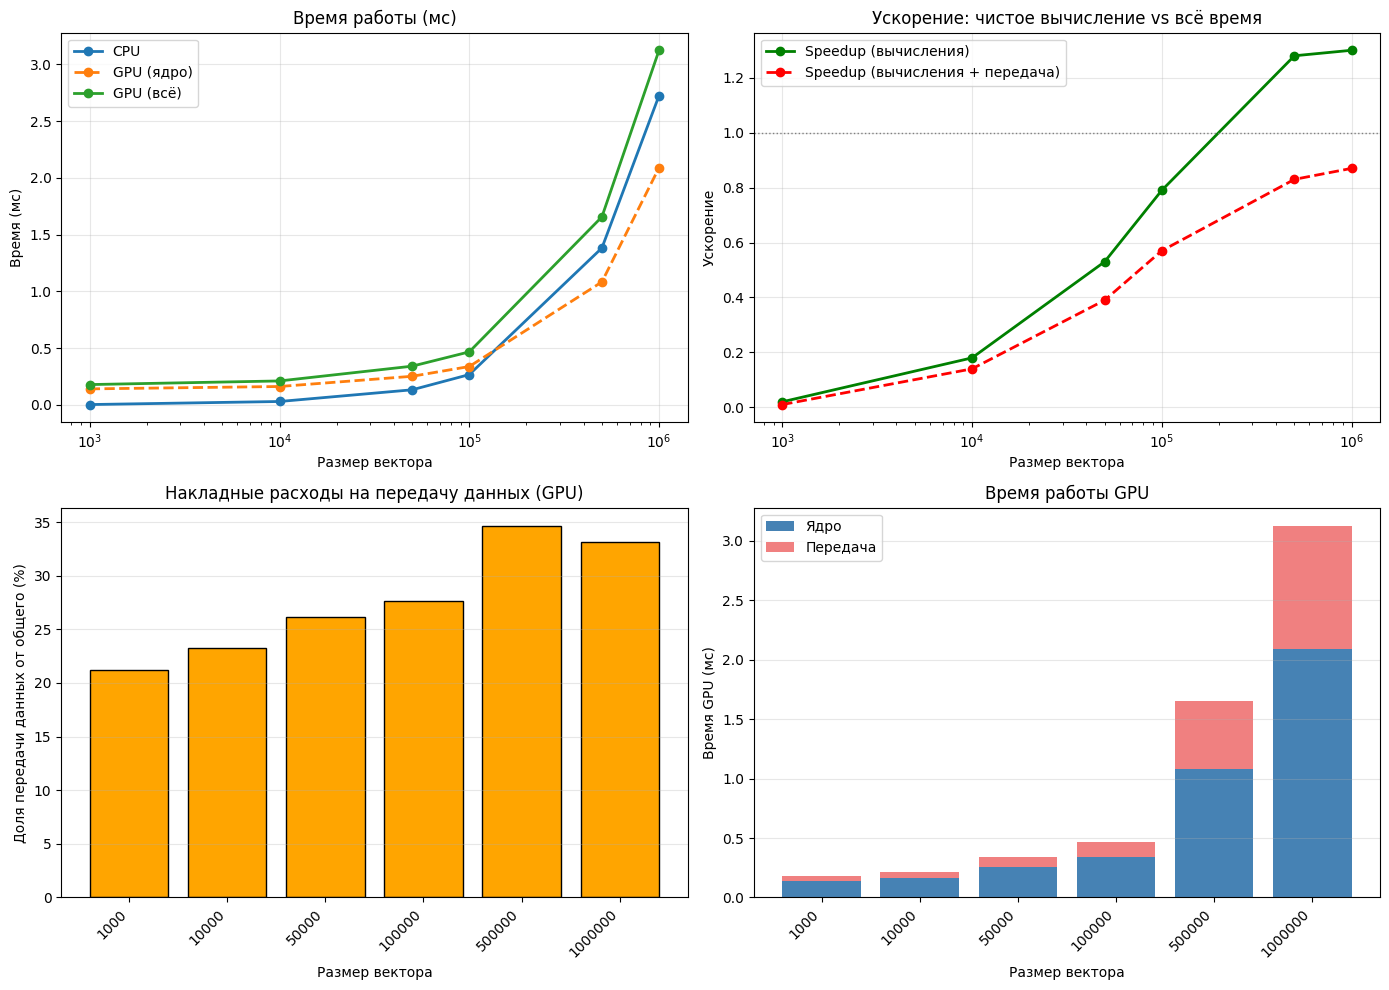


Результаты экспериментов:
   Size  CPU (ms)  GPU kernel (ms)  GPU transfer (ms)  GPU total (ms)  Speedup (kernel)  Speedup (total) Status
   1000     0.003            0.141              0.038           0.179              0.02             0.01     OK
  10000     0.030            0.162              0.049           0.211              0.18             0.14     OK
  50000     0.133            0.252              0.089           0.341              0.53             0.39     OK
 100000     0.267            0.338              0.129           0.467              0.79             0.57     OK
 500000     1.382            1.083              0.573           1.656              1.28             0.83     OK
1000000     2.724            2.089              1.034           3.123              1.30             0.87     OK


In [25]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

sizes = [1000, 10000, 50000, 100000, 500000, 1000000]
data = []

print("Запуск экспериментов...")
for n in sizes:
    out = subprocess.run(['./vector_sum', str(n)], capture_output=True, text=True)
    if out.returncode == 0:
        parts = out.stdout.strip().split(',')
        if len(parts) == 8:
            n, cpu, kernel, transfer, total, sp_kernel, sp_total, status = parts
            data.append({
                'Size': int(n),
                'CPU_ms': float(cpu),
                'GPU_kernel_ms': float(kernel),
                'GPU_transfer_ms': float(transfer),
                'GPU_total_ms': float(total),
                'Speedup_kernel': float(sp_kernel),
                'Speedup_total': float(sp_total),
                'Status': status
            })
            print(f"N={n}: CPU={cpu}ms, GPU(kernel)={kernel}ms, GPU(total)={total}ms, Speedup={sp_total}x, {status}")

df = pd.DataFrame(data)
plt.figure(figsize=(14, 10))

# 1. Время выполнения (логарифмическая шкала по X)
plt.subplot(2, 2, 1)
plt.plot(df['Size'], df['CPU_ms'], 'o-', label='CPU', linewidth=2)
plt.plot(df['Size'], df['GPU_kernel_ms'], 'o--', label='GPU (ядро)', linewidth=2)
plt.plot(df['Size'], df['GPU_total_ms'], 'o-', label='GPU (всё)', linewidth=2)
plt.xlabel('Размер вектора')
plt.ylabel('Время (мс)')
plt.title('Время работы (мс)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

# 2. Ускорение
plt.subplot(2, 2, 2)
plt.plot(df['Size'], df['Speedup_kernel'], 'o-', label='Speedup (вычисления)', color='green', linewidth=2)
plt.plot(df['Size'], df['Speedup_total'], 'o--', label='Speedup (вычисления + передача)', color='red', linewidth=2)
plt.axhline(1, color='gray', linestyle=':', linewidth=1)
plt.xlabel('Размер вектора')
plt.ylabel('Ускорение')
plt.title('Ускорение: чистое вычисление vs всё время')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

# 3. Доля передачи данных в общем времени GPU
plt.subplot(2, 2, 3)
df['Transfer_ratio'] = df['GPU_transfer_ms'] / df['GPU_total_ms'] * 100
plt.bar(df['Size'].astype(str), df['Transfer_ratio'], color='orange', edgecolor='black')
plt.xlabel('Размер вектора')
plt.ylabel('Доля передачи данных от общего (%)')
plt.title('Накладные расходы на передачу данных (GPU)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# 4. Визуализация времени выполнения на GPU
plt.subplot(2, 2, 4)
plt.bar(df['Size'].astype(str), df['GPU_kernel_ms'], label='Ядро', color='steelblue')
plt.bar(df['Size'].astype(str), df['GPU_transfer_ms'], bottom=df['GPU_kernel_ms'], label='Передача', color='lightcoral')
plt.xlabel('Размер вектора')
plt.ylabel('Время GPU (мс)')
plt.title('Время работы GPU')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nРезультаты экспериментов:")
display_df = df[['Size', 'CPU_ms', 'GPU_kernel_ms', 'GPU_transfer_ms', 'GPU_total_ms', 'Speedup_kernel', 'Speedup_total', 'Status']].copy()
display_df.columns = ['Size', 'CPU (ms)', 'GPU kernel (ms)', 'GPU transfer (ms)', 'GPU total (ms)', 'Speedup (kernel)', 'Speedup (total)', 'Status']
print(display_df.to_string(index=False))